# Highlighting

When a figure carries many series, the story is usually about one of them: one model run among its competitors, one cohort inside the population, one trend over raw observations. The `emphasis` parameter expresses that relationship directly — per chart, not via global styling:

- `"background"` mutes a series: it takes the active theme's `muted_color` at `muted_alpha`, gets thinner strokes, drops behind the other series, claims no color-cycle slot, and is excluded from the legend.
- `"highlight"` bolds a series and brings it to the front of the data layers (never above axes or reference lines). It keeps its theme-assigned color and legend entry.
- Leaving it unset (`None`) draws the series exactly as before.

`emphasis` is accepted by `LineChart`, `BarChart`, `ScatterChart`, `Histogram`, `ParallelCoords` (per data row), and `BoxPlot` (per box label), and as a per-figure `"emphasis"` option in `Panel`. Bar records — in `BarChart`, `PyramidChart`, and the `RadialChart` bar visual — also carry their own `"emphasis"` key. Every chart that carries emphasis, plus `Heatmap` and `HexbinChart`, also takes an `emphasis_rule` that fills the roles in from the values — see [Emphasis picked by a rule](#emphasis-picked-by-a-rule). Because muting derives from the theme's `muted_color`/`muted_alpha` attributes, background series harmonize with whatever theme is active. The role strings are also available as constants: `datachart.constants.EMPHASIS.BACKGROUND` and `EMPHASIS.HIGHLIGHT`.

In [1]:
import numpy as np

from datachart.charts import (
    BarChart,
    BoxPlot,
    Heatmap,
    HexbinChart,
    Histogram,
    LineChart,
    ParallelCoords,
    ScatterChart,
)
from datachart.utils import Panel
from datachart.config import config
from datachart.constants import SORT, THEME

## One Walk Among Many

The `emphasis` list aligns with the charts, like `style` and `subtitle`. Background walks fade into context; the highlighted walk keeps its cycle color and doubles its line width. Only emphasized-or-unset series appear in the legend.

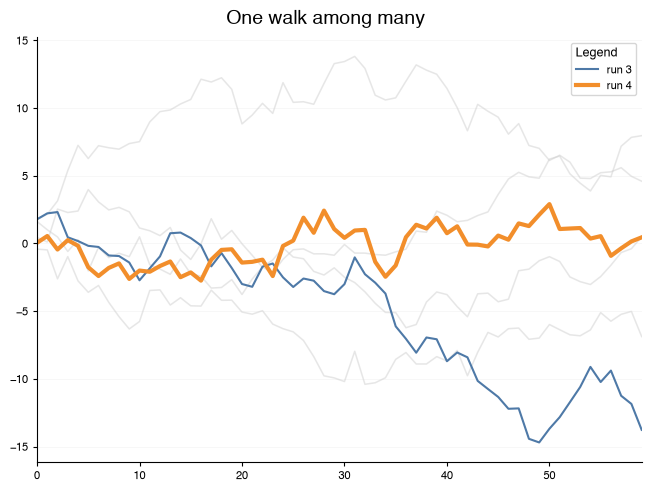

In [2]:
def walk(seed, n=60):
    rng = np.random.RandomState(seed)
    return [{"x": i, "y": float(v)} for i, v in enumerate(np.cumsum(rng.randn(n)))]

walks = [walk(seed) for seed in range(6)]

figure = LineChart(
    data=walks,
    subtitle=[f"run {i}" for i in range(6)],
    emphasis=["background", "background", "background", None, "highlight", "background"],
    show_legend=True,
    title="One walk among many",
)
figure.show()

## The Same Figure Under Another Theme

Muting is defined by the theme's `muted_color` and `muted_alpha` attributes, so the same chart code stays harmonious under any theme — no hand-picked greys.

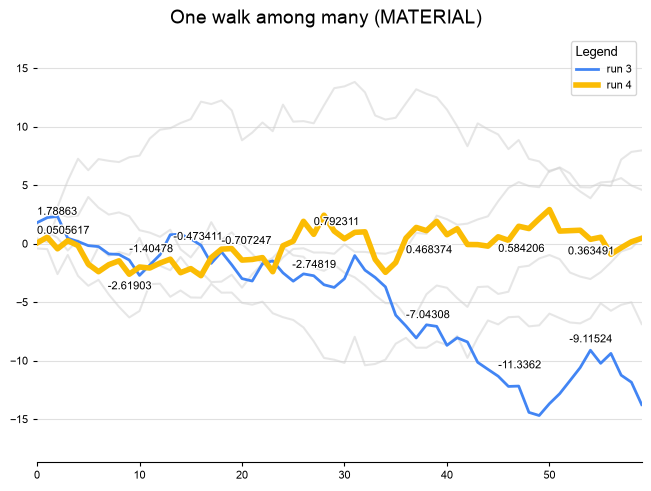

In [3]:
config.set_theme(THEME.MATERIAL)

figure = LineChart(
    data=walks,
    subtitle=[f"run {i}" for i in range(6)],
    emphasis=["background", "background", "background", None, "highlight", "background"],
    show_legend=True,
    title="One walk among many (MATERIAL)",
)
figure.show()

config.reset_config()

## A Cohort Inside a Scatter Cloud

A highlighted scatter series keeps its marker size but gains a contrasting edge; the background cloud recedes without disappearing.

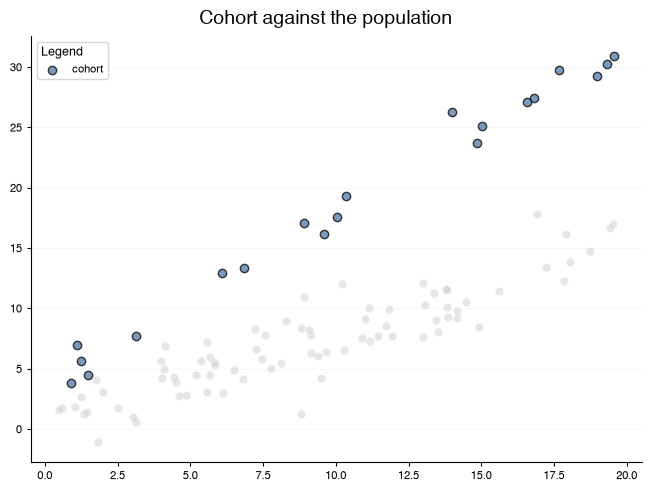

In [4]:
rng = np.random.RandomState(3)
population = [
    {"x": float(x), "y": float(x * 0.8 + rng.randn() * 2)}
    for x in rng.rand(80) * 20
]
cohort = [
    {"x": float(x), "y": float(x * 1.4 + 4 + rng.randn())}
    for x in rng.rand(20) * 20
]

figure = ScatterChart(
    data=[population, cohort],
    subtitle=["population", "cohort"],
    emphasis=["background", "highlight"],
    show_legend=True,
    title="Cohort against the population",
)
figure.show()

## Best Runs in Parallel Coordinates

For `ParallelCoords` the `emphasis` list aligns with the data **rows**. Highlighted rows come forward but stay below the axis furniture, so the axis lines and tick labels remain readable.

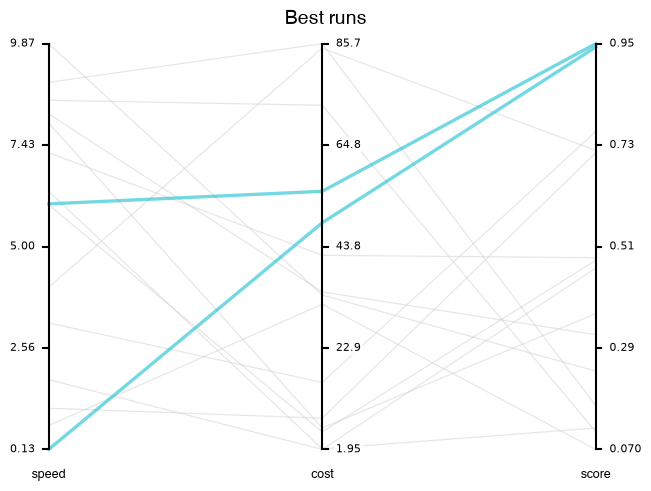

In [5]:
rng = np.random.RandomState(11)
runs = [
    {
        "speed": float(rng.rand() * 10),
        "cost": float(rng.rand() * 100),
        "score": float(rng.rand()),
    }
    for _ in range(15)
]
best = sorted(range(len(runs)), key=lambda i: runs[i]["score"])[-2:]

figure = ParallelCoords(
    data=runs,
    dimensions=["speed", "cost", "score"],
    emphasis=["highlight" if i in best else "background" for i in range(len(runs))],
    title="Best runs",
)
figure.show()

## A Cohort Against a Reference Distribution

Multi-series histograms normally draw stacked. Stacking a muted background is meaningless, so as soon as any series carries an emphasis role the histograms draw individually overlaid — on shared bins, with the background distribution behind the cohort.

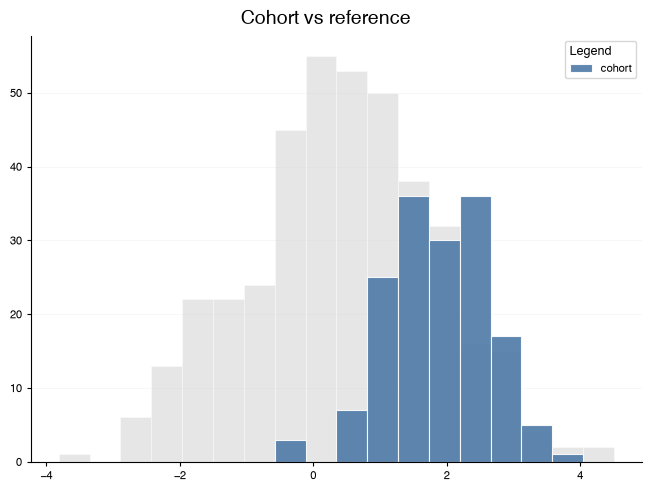

In [6]:
rng = np.random.RandomState(7)
reference = [{"x": float(v)} for v in rng.randn(400) * 1.4 + 0.5]
cohort = [{"x": float(v)} for v in rng.randn(160) * 0.8 + 2.0]

figure = Histogram(
    data=[reference, cohort],
    subtitle=["reference", "cohort"],
    emphasis=["background", None],
    num_bins=18,
    show_legend=True,
    title="Cohort vs reference",
)
figure.show()

## Per-Label Emphasis in a Box Plot

Box charts never overlay, so their `emphasis` aligns with the box **labels** of one call. Whiskers, caps, medians, and outliers mute together with their box; a highlighted box gets bolder edges and a bolder median.

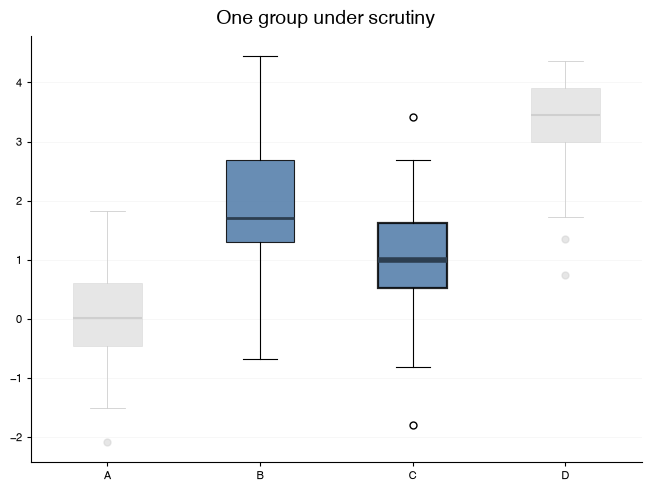

In [7]:
rng = np.random.RandomState(9)
data = [
    {"label": lab, "value": float(v + off)}
    for lab, off in [("A", 0.0), ("B", 2.0), ("C", 1.0), ("D", 3.0)]
    for v in rng.randn(30)
]

figure = BoxPlot(
    data=data,
    emphasis=["background", None, "highlight", "background"],
    title="One group under scrutiny",
)
figure.show()

## Emphasis Picked by a Rule

Often the emphasis follows from the data — the best runs, the groups above a target, the densest region — and writing the roles by hand repeats what the values already say. `emphasis_rule` is a one-key dict that highlights every unit matching it and mutes the rest:

| Rule | Highlights |
| :--- | :--------- |
| `{"above": v}`, `{"below": v}` | values strictly above or below `v` |
| `{"between": (lo, hi)}` | values from `lo` to `hi`, both included |
| `{"top": n}`, `{"bottom": n}` | the `n` largest or smallest values; ties keep input order |

Each chart applies the rule to the unit it already gives emphasis to, and reads one number per unit:

| Unit | Number the rule reads |
| :--- | :-------------------- |
| a bar record, treemap leaf, or network node | its own value: `y`, `value`, or `size` |
| a parallel coordinates row | its numeric `hue` value |
| a heatmap cell or hexbin bin | the cell value, or the bin's aggregated value |
| a group of a box, violin, swarm, or raincloud plot | a summary of the group's values, the median by default |
| a series of a line, scatter, stacked area, histogram, or line contour chart | a summary of the series' values, the mean by default |

Groups and series take an optional `"by"` key next to the rule — `"mean"`, `"median"`, `"min"`, `"max"`, or `"sum"` — to choose the summary; a chart that reads one value per unit rejects it. On every chart an explicit role wins over the rule, and `top`/`bottom` rank across every unit of the call, across subplots too — except hexbin bins, which exist only once drawn and rank within their own chart. The rule's shape is documented in [EmphasisRuleAttrs](../../../references/typings/#datachart.typings.EmphasisRuleAttrs).

### Bars

A bar chart's emphasis can come from the data instead of a hand-written list. `emphasis_rule` is a one-key dict — `{"above": v}`, `{"below": v}`, `{"between": (lo, hi)}`, `{"top": n}`, or `{"bottom": n}` — that highlights every bar matching it and mutes the rest; the contrast is the point, so the rule commits to both ends. Each bar record may also carry its own `"emphasis"` key, and an explicit record role always wins over the rule, which is how "the top three, and also this one" is said. `sort` orders the categories by value so the ranking reads left to right; it never changes which bars the rule picks.

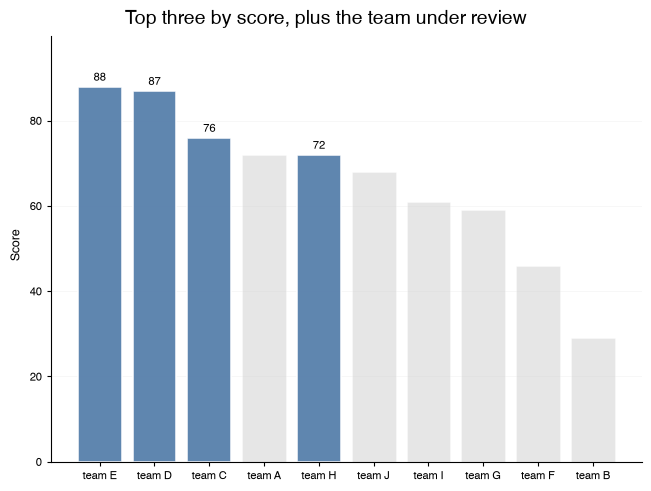

In [8]:
rng = np.random.RandomState(13)
teams = [
    {"label": f"team {chr(65 + i)}", "y": float(round(rng.rand() * 80 + 10))}
    for i in range(10)
]
# the team under review is highlighted whatever its score
teams[7]["emphasis"] = "highlight"

figure = BarChart(
    data=teams,
    title="Top three by score, plus the team under review",
    ylabel="Score",
    sort=SORT.DESCENDING,
    emphasis_rule={"top": 3},
    show_values=True,
    value_format="{:.0f}",
)
figure.show()

### Series

The random walks from above, picked by their peak instead of by hand: `"by": "max"` summarises each walk by its highest point, and `{"top": 2}` keeps the two highest.

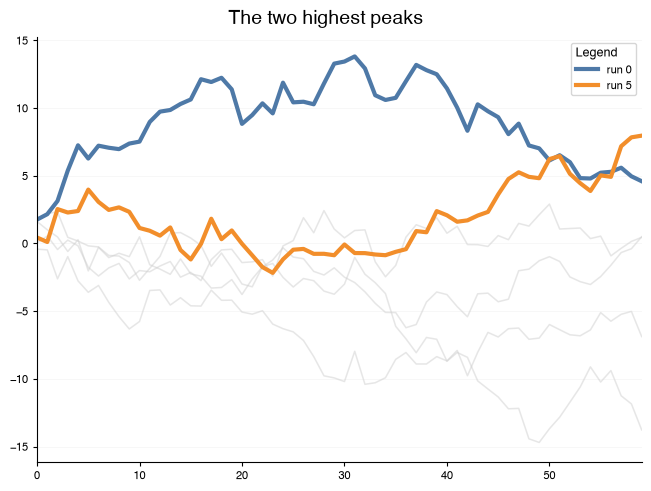

In [9]:
figure = LineChart(
    data=walks,
    subtitle=[f"run {i}" for i in range(6)],
    emphasis_rule={"top": 2, "by": "max"},
    show_legend=True,
    title="The two highest peaks",
)
figure.show()

### Groups

The box plot from above, with the groups picked by their median. The rule reads the same median line the box draws, so the highlighted boxes are the ones whose line clears the threshold.

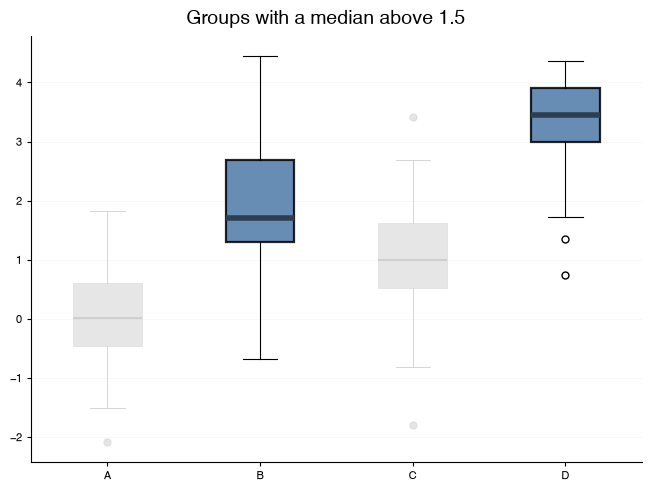

In [10]:
figure = BoxPlot(
    data=data,
    emphasis_rule={"above": 1.5},
    title="Groups with a median above 1.5",
)
figure.show()

### Records

Parallel coordinates read the rule against each row's `hue` value — the column the rows are already colored by — so the best runs from above no longer need a hand-built role list. The highlighted rows keep the hue ramp, spread over their own scores.

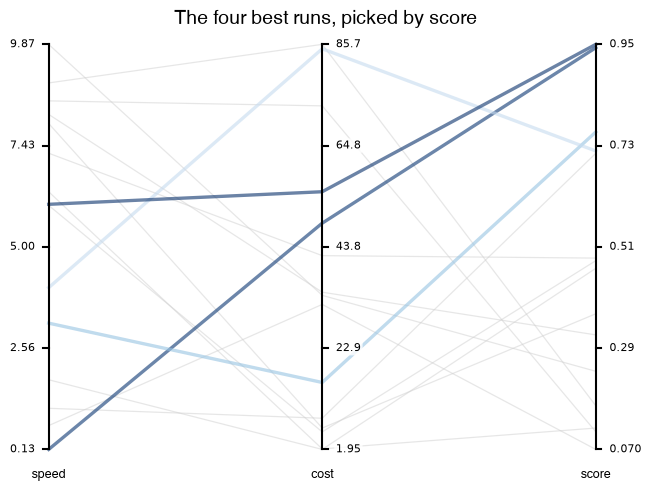

In [11]:
figure = ParallelCoords(
    data=runs,
    dimensions=["speed", "cost", "score"],
    hue="score",
    emphasis_rule={"top": 4},
    title="The four best runs, picked by score",
)
figure.show()

### Cells and Bins

A heatmap cell fades to the theme's `muted_alpha` when muted, so it still reads on the colormap, and a highlighted cell is outlined; a blank cell never matches. Cells also take explicit roles through an `emphasis` grid aligned with `z`, which wins over the rule. A hexbin's bins exist only once they are drawn, so `HexbinChart` takes the rule alone, read against each bin's count (or its reduced `c` value).

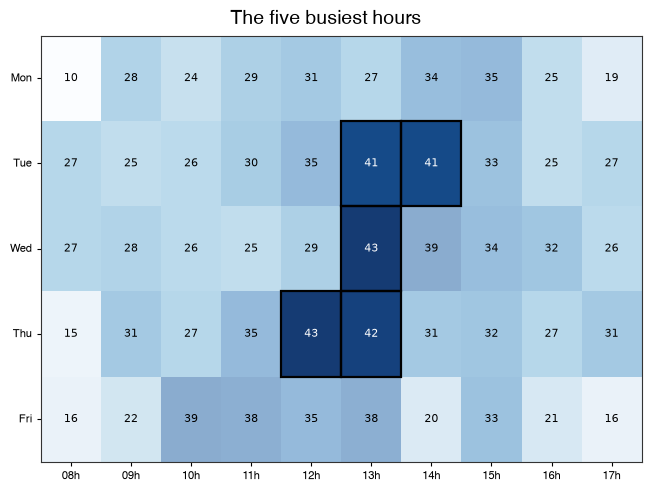

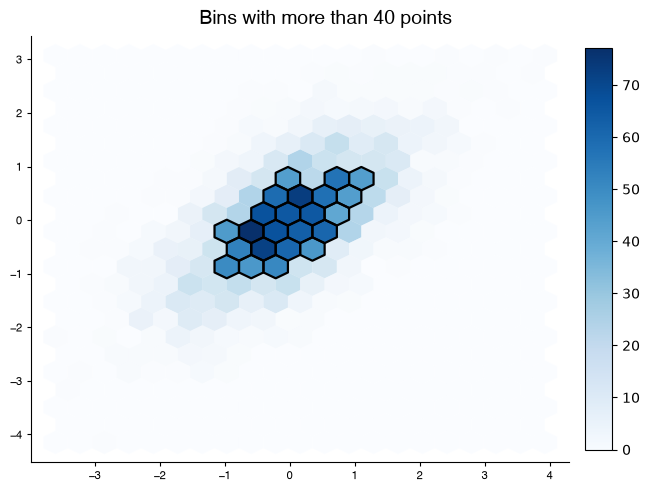

In [12]:
rng = np.random.RandomState(21)
hours = [f"{h:02d}h" for h in range(8, 18)]
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
load = {
    "x": hours,
    "y": days,
    "z": [[int(rng.poisson(20 + 15 * np.sin((h - 8) / 3))) for h in range(8, 18)] for _ in days],
}

figure = Heatmap(
    data=load,
    emphasis_rule={"top": 5},
    show_heatmap_values=True,
    title="The five busiest hours",
)
figure.show()

points = rng.multivariate_normal([0, 0], [[1, 0.6], [0.6, 1]], size=3000)
figure = HexbinChart(
    data={"x": points[:, 0].tolist(), "y": points[:, 1].tolist()},
    gridsize=20,
    emphasis_rule={"above": 40},
    show_colorbars=True,
    title="Bins with more than 40 points",
)
figure.show()

## Composing Context and Focus with Panel

`Panel` accepts a per-figure `"emphasis"` option next to `y_axis`, `z_order`, and `legend_label`. The role applies to every layer of that figure — here the raw observations become context under a highlighted trend. The muted figure drops out of the legend automatically.

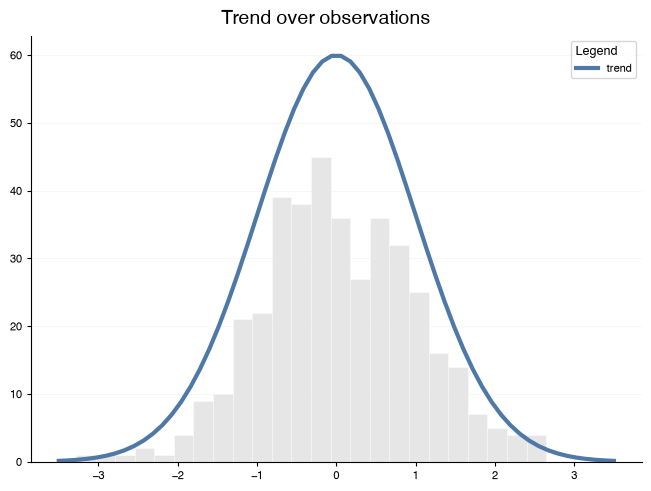

In [13]:
rng = np.random.RandomState(5)
observations = [{"x": float(v)} for v in rng.randn(400)]
xs = np.linspace(-3.5, 3.5, 60)
trend = [{"x": float(x), "y": float(60 * np.exp(-x * x / 2))} for x in xs]

hist_fig = Histogram(data=observations, num_bins=24, subtitle="observations")
trend_fig = LineChart(data=trend, subtitle="trend")

figure = Panel(
    [
        {"figure": hist_fig, "emphasis": "background"},
        {"figure": trend_fig, "emphasis": "highlight"},
    ],
    title="Trend over observations",
    show_legend=True,
)
figure.show()

Composed parallel-coordinates figures also normalize against shared per-dimension ranges inside a `Panel`, so a muted context figure and a highlighted runs figure line up on the same axis scales.